In [5]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

from src.datasets import get_dataloaders
from src.models import ResNet18Classifier
from src.trainer import train_one_epoch, validate
from src.evaluate import print_report, plot_confusion_matrix

In [7]:
DATA_DIR = "/home/divye/Desktop/cnn/data/2750"

train_loader, val_loader, classes, class_to_idx = get_dataloaders(
    DATA_DIR,
    batch_size=32
)

In [8]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = ResNet18Classifier(
    num_classes=len(classes)
).to(device)

In [9]:
model.freeze_backbone()

In [10]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

In [11]:
best_acc = 0
PHASE1_EPOCHS = 3

for epoch in range(PHASE1_EPOCHS):

    print(f"\nPhase 1 - Epoch {epoch+1}/{PHASE1_EPOCHS}")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    val_loss, val_acc, preds, targets = validate(
        model,
        val_loader,
        criterion,
        device
    )

    print(f"Train Acc : {train_acc:.4f}")
    print(f"Val Acc   : {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(
            model.state_dict(),
            "../checkpoints/resnet18_phase1.pt"
        )


Phase 1 - Epoch 1/3


100%|██████████| 675/675 [05:56<00:00,  1.89it/s]


Train Acc : 0.7803
Val Acc   : 0.8541

Phase 1 - Epoch 2/3


100%|██████████| 675/675 [05:12<00:00,  2.16it/s]


Train Acc : 0.8621
Val Acc   : 0.8839

Phase 1 - Epoch 3/3


100%|██████████| 675/675 [05:30<00:00,  2.04it/s]


Train Acc : 0.8692
Val Acc   : 0.8785


In [12]:
model.unfreeze_last_blocks()

In [14]:
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

In [15]:
PHASE2_EPOCHS = 5

for epoch in range(PHASE2_EPOCHS):

    print(f"\nPhase 2 - Epoch {epoch+1}/{PHASE2_EPOCHS}")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    val_loss, val_acc, preds, targets = validate(
        model,
        val_loader,
        criterion,
        device
    )

    print(f"Train Acc : {train_acc:.4f}")
    print(f"Val Acc   : {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(
            model.state_dict(),
            "../checkpoints/resnet18_best.pt"
        )
        


Phase 2 - Epoch 1/5


100%|██████████| 675/675 [05:57<00:00,  1.89it/s]


Train Acc : 0.9239
Val Acc   : 0.9637

Phase 2 - Epoch 2/5


100%|██████████| 675/675 [06:03<00:00,  1.86it/s]


Train Acc : 0.9532
Val Acc   : 0.9517

Phase 2 - Epoch 3/5


...

Train Acc : 0.9661
Val Acc   : 0.9680

Phase 2 - Epoch 4/5


100%|██████████| 675/675 [05:43<00:00,  1.96it/s]


Train Acc : 0.9670
Val Acc   : 0.9680

Phase 2 - Epoch 5/5


100%|██████████| 675/675 [06:02<00:00,  1.86it/s]


Train Acc : 0.9745
Val Acc   : 0.9698


                      precision    recall  f1-score   support

          AnnualCrop       0.96      0.98      0.97       631
              Forest       0.98      0.99      0.99       582
HerbaceousVegetation       0.93      0.96      0.95       612
             Highway       0.96      0.98      0.97       525
          Industrial       1.00      0.97      0.98       484
             Pasture       0.96      0.96      0.96       396
       PermanentCrop       0.98      0.88      0.93       506
         Residential       0.97      1.00      0.99       606
               River       0.98      0.98      0.98       497
             SeaLake       0.99      0.99      0.99       561

            accuracy                           0.97      5400
           macro avg       0.97      0.97      0.97      5400
        weighted avg       0.97      0.97      0.97      5400



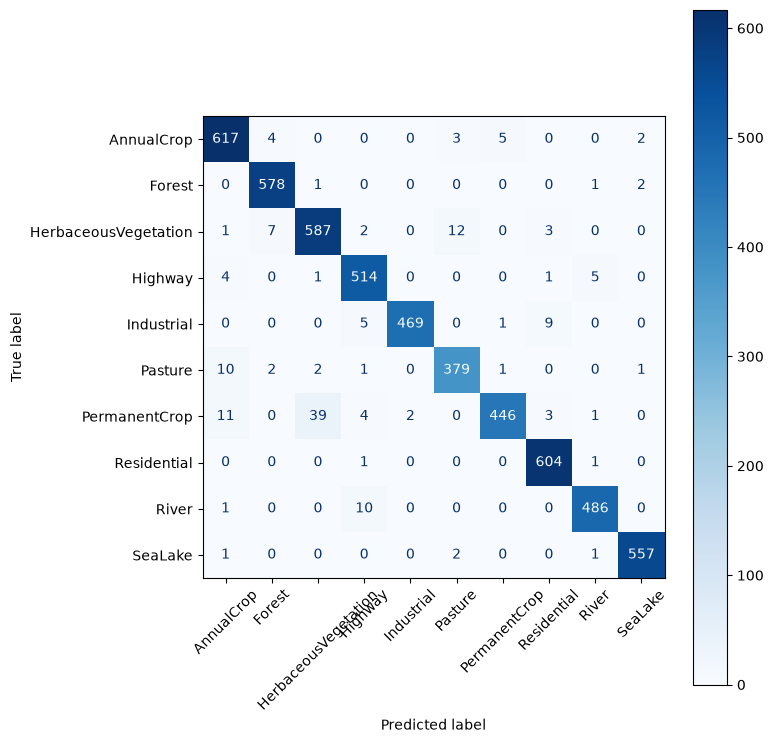

In [16]:
print_report(
    targets,
    preds,
    classes
)

plot_confusion_matrix(
    targets,
    preds,
    classes
)